Dataset Loaded ✅
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')
['positive' 'negative']
0
['positive' 'negative']
review       0
sentiment    0
dtype: int64

Sentiment Count:
sentiment
0    1997
1    1955
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7365 - loss: 0.5460 - val_accuracy: 0.8710 - val_loss: 0.3300
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9421 - loss: 0.1781 - val_accuracy: 0.8622 - val_loss: 0.3212
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9918 - loss: 0.0443 - val_accuracy: 0.8445 - val_loss: 0.4171
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9997 - loss: 0.0108 - val_accuracy: 0.8609 - val_loss: 0.4457
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8609 - val_loss: 0.4797
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8571 - val_loss: 0.5075
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8584 - val_loss: 0.5309
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 7.7560e-04 - val_accuracy: 0.8571

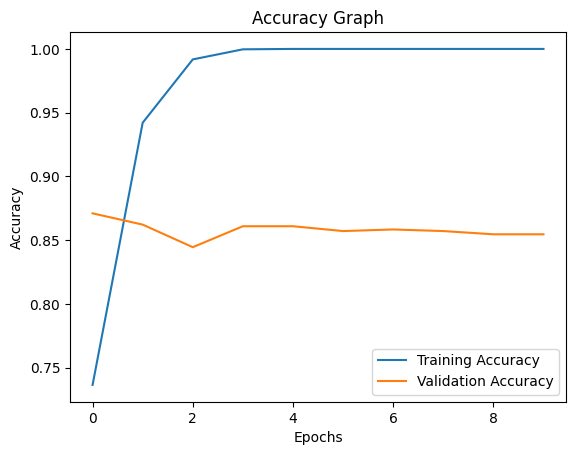

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8546 - loss: 0.5857

Final Accuracy: 0.8546144366264343


In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

print("Dataset Loaded ✅")
print(df.head())
print(df.columns)

df = df.dropna()
print(df['sentiment'].unique())
print(df['sentiment'].isnull().sum())
df = df.dropna()

print(df['sentiment'].unique())   # should be [0,1]
print(df.isnull().sum())          # should be 0

# =========================
# 3. FIX COLUMN NAMES
# =========================
df.columns = ['review', 'sentiment']

# =========================
# 4. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      # remove HTML
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove symbols
    return text

df['review'] = df['review'].apply(clean_text)

# =========================
# 5. CONVERT LABELS
# =========================
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\nSentiment Count:")
print(df['sentiment'].value_counts())

# =========================
# 6. TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8. BUILD MODEL
# =========================
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================
# 10. PLOT GRAPH
# =========================
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# =========================
# 11. FINAL ACCURACY
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Accuracy:", accuracy)